#**CHAPTER 1.BAYESIAN PATTERN RECOGNITION**
---

##REFERENCE

https://chatgpt.com/share/69acbf2d-db54-8012-891c-6d9bb26e90d9

##0.CONTEXT

**Introduction**

This notebook is designed as a rigorous laboratory in Bayesian machine learning for financial pattern recognition. Its purpose is not to produce a toy classifier, nor to simulate a simplistic market environment with arbitrary noise, but rather to build a controlled experimental setting in which uncertainty, latent structure, and cross-asset dependence can be studied in a principled way. In financial applications, pattern recognition is rarely a matter of cleanly assigning one label to one observation. Instead, it is a problem of inference under ambiguity. A given block of returns may be consistent with a calm market, a stressed market, or a transitional market undergoing structural rotation. The essential scientific question is therefore not only “what regime is this?” but also “how certain should we be about that conclusion?” This notebook is built around that stronger and more realistic question.

The notebook uses synthetic multi-asset data because synthetic environments allow full control over the hidden mechanisms generating the data. In empirical finance, one rarely knows the true latent regime, the true covariance geometry, or the exact source of apparent structure. By contrast, in a synthetic setting one can deliberately construct a market with regime persistence, volatility clustering, correlation spikes, factor-driven rotation, and unequal asset sensitivities. This makes it possible to evaluate whether a Bayesian model recovers meaningful latent patterns rather than merely fitting noise. The synthetic design also aligns with governance-first and scientific best practice because it avoids external data dependency, avoids data licensing issues, and makes the entire experiment reproducible from a deterministic seed.

The central methodological choice is the use of Bayesian learning rather than a purely deterministic classifier. This choice matters deeply in finance. Financial observations are noisy, sample sizes are finite, and the distinction between regimes is often blurred. A deterministic model estimates parameters and then behaves as if they were known with certainty. A Bayesian model treats those parameters themselves as uncertain, updates beliefs in light of data, and propagates that uncertainty into the predictive distribution. In the notebook, this is implemented through a Normal–Inverse-Wishart prior for class-conditional multivariate features, yielding a multivariate Student-t posterior predictive distribution. This is scientifically meaningful because the predictive density reflects both the observed structure in the data and the uncertainty remaining about the regime parameters.

The broader educational aim of the notebook is to connect three domains that are often taught separately: advanced probabilistic machine learning, realistic financial structure, and high-quality scientific computing. The notebook therefore combines a latent-state synthetic market generator, a robust feature-construction pipeline based on rolling multi-asset windows, a Bayesian posterior predictive classifier, a deterministic comparator, quantitative evaluation metrics, and a final large-language-model interpretation cell. That final cell is not included for novelty alone. It is meant to demonstrate how modern reasoning models can be used to generate a disciplined narrative interpretation of probabilistic results, provided that the underlying experiment has already been structured, quantified, and logged properly.

The notebook should therefore be read as a compact doctoral laboratory. It is computationally lightweight enough to run in Colab, but intellectually it is intended to operate at a high level. It asks the reader to think about latent financial structure, posterior inference, calibration, ambiguity, and model comparison. Most importantly, it emphasizes that in finance the real value of a model often lies not in the sharpness of its classification, but in the honesty of its uncertainty.

##1.LIBRARIES AND ENVIRONMENT

**Explanation of Cell 1**

Cell 1 establishes the scientific working environment for the notebook. At a surface level, it loads the required Python modules, sets a deterministic seed, defines a few utility functions, and creates a directory for artifacts. But its deeper purpose is methodological discipline. In a research notebook, the setup cell is not just administrative boilerplate. It is the place where reproducibility, numerical stability, and output organization are explicitly declared.

The deterministic seed is especially important. Because the notebook relies on synthetic data generation, the seed ensures that every run can reproduce the same latent regimes, the same return trajectories, and the same inference results. Without this step, the notebook would become a moving target, making debugging and interpretation unnecessarily difficult. The seed therefore acts as a control mechanism that turns a stochastic experiment into a reproducible computational object.

The artifact directory created in this cell is also significant. Rather than letting the notebook exist only as transient output on screen, the code prepares a structured location in which summaries, diagnostics, and later interpretive outputs can be saved. This helps make the notebook feel more like a serious laboratory than an informal coding demo. The helper functions defined here also contribute to that goal. They simplify repeated operations such as printing labeled sections, enforcing positive-definite covariance matrices, and saving machine-readable JSON files. These are small details, but together they create a foundation for robust notebook design.

In scientific terms, Cell 1 says: this notebook is not improvisational. It is deterministic, auditable, and structured from the beginning.

In [6]:
# Cell 1
# Environment, deterministic setup, lightweight dependencies, scientific display helpers

import os
import sys
import math
import json
import time
import textwrap
import warnings
import subprocess
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.special import gammaln, logsumexp
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scipy"])
    from scipy.special import gammaln, logsumexp

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

ARTIFACT_DIR = Path("bayesian_finance_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.22
plt.rcParams["font.size"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

def print_banner(title: str) -> None:
    line = "=" * len(title)
    print(f"\n{line}\n{title}\n{line}\n")

def section(title: str) -> None:
    print(f"\n[SECTION] {title}")

def stable_softmax(logits: np.ndarray, axis: int = -1) -> np.ndarray:
    z = logits - np.max(logits, axis=axis, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=axis, keepdims=True)

def ensure_spd(a: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    a = 0.5 * (a + a.T)
    vals, vecs = np.linalg.eigh(a)
    vals = np.maximum(vals, eps)
    return vecs @ np.diag(vals) @ vecs.T

def save_json(obj, path: Path) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

print_banner("Bayesian Advanced Machine Learning for Financial Pattern Recognition")
print("Deterministic seed:", SEED)
print("Artifact directory:", ARTIFACT_DIR.resolve())
print("Libraries: numpy, matplotlib, scipy")


Bayesian Advanced Machine Learning for Financial Pattern Recognition

Deterministic seed: 42
Artifact directory: /content/bayesian_finance_artifacts
Libraries: numpy, matplotlib, scipy


## 2.RESEARCH FRAMING

###2.1.OVERVIEW

**Explanation of Cell 2**

Cell 2 provides the conceptual and experimental framing of the notebook, but it does so in executable form. Instead of placing the notebook’s motivation only in prose, the cell stores the research framing and the experiment configuration directly in Python objects. This is a professional design choice because it makes the scientific assumptions part of the computational record.

The introductory text in this cell explains why Bayesian learning is attractive for finance. It emphasizes that financial pattern recognition is fundamentally a problem of uncertainty, not just a problem of label assignment. That is the intellectual anchor of the notebook. Regime inference in finance must deal with instability, overlap, and noise, and so the notebook must be designed around posterior reasoning rather than mere classification accuracy.

The experiment configuration is equally important. It defines the number of assets, number of time steps, number of latent regimes, window size for rolling features, and training fraction. By making these parameters explicit, the notebook becomes easier to understand, modify, and reproduce. A future researcher can change the scale of the experiment without rewriting the full codebase. The configuration is also saved to disk, which means that the notebook’s design choices are recorded alongside the results they generated.

In a deeper sense, Cell 2 turns the notebook into a formal experiment rather than a narrative. It identifies the problem, the data scale, and the latent structure assumptions in a way that is both human-readable and machine-readable. That is a hallmark of mature scientific computing.

###2.2.CODE AND IMPLEMENTATION

In [8]:
# Cell 2
# Research framing, notebook metadata, and scientific problem definition as executable code

INTRO_TEXT = """
Bayesian machine learning is especially attractive in finance because pattern recognition
must be performed under uncertainty, instability, overlapping regimes, and noisy cross-asset
structure. In this notebook we build a synthetic multi-asset market with latent regimes,
time-varying volatility, regime-dependent covariance geometry, and heterogeneous factor pressure.

The scientific objective is not simply classification. The objective is posterior regime inference:
given a rolling window of multi-asset observations, what is the probability that the window belongs
to each latent financial regime, and where is that inference uncertain?

We use a class-conditional Bayesian multivariate model with a Normal-Inverse-Wishart prior.
That yields a multivariate Student-t posterior predictive distribution for each regime. This is a
material step beyond deterministic plug-in estimation because parameter uncertainty is integrated
into prediction rather than ignored.
"""

EXPERIMENT_CONFIG = {
    "seed": SEED,
    "n_assets": 10,
    "n_steps": 2200,
    "n_regimes": 3,
    "window": 40,
    "step": 5,
    "train_fraction": 0.65,
    "artifact_dir": str(ARTIFACT_DIR),
    "regime_names": {
        0: "Calm carry / segmented low-vol regime",
        1: "Stress contagion / high-vol correlation spike",
        2: "Rotation / factor conflict regime"
    }
}

section("Problem framing")
print(textwrap.fill(INTRO_TEXT.strip(), width=100))
section("Experiment config")
for k, v in EXPERIMENT_CONFIG.items():
    print(f"{k}: {v}")

save_json(EXPERIMENT_CONFIG, ARTIFACT_DIR / "experiment_config.json")
print("\nSaved experiment_config.json")


[SECTION] Problem framing
Bayesian machine learning is especially attractive in finance because pattern recognition must be
performed under uncertainty, instability, overlapping regimes, and noisy cross-asset structure. In
this notebook we build a synthetic multi-asset market with latent regimes, time-varying volatility,
regime-dependent covariance geometry, and heterogeneous factor pressure.  The scientific objective
is not simply classification. The objective is posterior regime inference: given a rolling window of
multi-asset observations, what is the probability that the window belongs to each latent financial
regime, and where is that inference uncertain?  We use a class-conditional Bayesian multivariate
model with a Normal-Inverse-Wishart prior. That yields a multivariate Student-t posterior predictive
distribution for each regime. This is a material step beyond deterministic plug-in estimation
because parameter uncertainty is integrated into prediction rather than ignored.

[SE

##3.SYNTHETIC MULTI ASSET GENERATOR

###3.1.OVERVIEW

**Explanation of Cell 3**

Cell 3 is the generative heart of the notebook. It builds the synthetic financial world within which all later pattern recognition takes place. This cell does much more than create random returns. It designs a multi-asset market with economically meaningful latent regimes, each associated with a distinct covariance geometry, mean profile, and volatility intensity.

The regime process is generated through a Markov transition matrix, which introduces persistence into market states. This matters because financial regimes are rarely independent from one period to the next. Stress tends to cluster, calm tends to persist, and transitions between states are often gradual rather than instantaneous. By using a Markov chain, the notebook captures that temporal logic.

The regimes themselves are differentiated in deliberate ways. One regime is relatively calm, with moderate segmentation across assets and lower volatility. Another is a stress regime, where volatility is much higher and cross-asset correlation spikes, mimicking contagion-like behavior often seen in crises. The third regime introduces rotational or factor-conflict structure, in which some assets benefit while others deteriorate. This is especially valuable because it goes beyond a simple calm-versus-crisis dichotomy and creates a richer classification landscape.

The cell also incorporates stochastic scaling based on recent returns, so that realized volatility is path dependent rather than fixed. This makes the synthetic market more realistic. Prices are then generated by compounding log returns, and the resulting arrays are stored for downstream use. The output of Cell 3 is therefore a full synthetic market ecosystem: latent states, returns, prices, and supporting regime parameters.

Scientifically, this cell matters because it creates the hidden truth against which later inference can be evaluated. Without a carefully designed generator, Bayesian learning would have nothing meaningful to discover.

###3.2.CODE AND IMPLEMENTATION

In [9]:
# Cell 3
# Synthetic multi-asset market generator with latent regimes, factor pressure, structural breaks, and stochastic volatility

def build_block_corr(n: int, intra: float, inter: float) -> np.ndarray:
    c = np.full((n, n), inter, dtype=float)
    half = n // 2
    c[:half, :half] = intra
    c[half:, half:] = intra
    np.fill_diagonal(c, 1.0)
    return c

def build_stress_corr(n: int, level: float) -> np.ndarray:
    c = np.full((n, n), level, dtype=float)
    np.fill_diagonal(c, 1.0)
    return c

def build_factor_corr(n: int, strength: float) -> np.ndarray:
    v = np.linspace(-1.0, 1.0, n)
    v = v / np.linalg.norm(v)
    c = (1.0 - strength) * np.eye(n) + strength * np.outer(v, v)
    d = np.sqrt(np.diag(c))
    c = c / np.outer(d, d)
    np.fill_diagonal(c, 1.0)
    return c

def simulate_markov_states(T: int, P: np.ndarray, init_state: int, rng: np.random.Generator) -> np.ndarray:
    s = np.zeros(T, dtype=int)
    s[0] = init_state
    for t in range(1, T):
        s[t] = rng.choice(P.shape[0], p=P[s[t - 1]])
    return s

def simulate_market(config: dict, rng: np.random.Generator) -> dict:
    T = config["n_steps"]
    N = config["n_assets"]

    P = np.array([
        [0.975, 0.017, 0.008],
        [0.055, 0.915, 0.030],
        [0.035, 0.025, 0.940]
    ], dtype=float)

    states = simulate_markov_states(T, P, init_state=0, rng=rng)

    mu = {
        0: np.array([0.0007, 0.0006, 0.0005, 0.0003, 0.0004, 0.0002, 0.0001, 0.0002, 0.0001, 0.0000])[:N],
        1: np.array([-0.0018, -0.0015, -0.0016, -0.0013, -0.0012, -0.0011, -0.0009, -0.0010, -0.0008, -0.0009])[:N],
        2: np.array([0.0012, 0.0007, -0.0004, -0.0008, 0.0010, 0.0001, -0.0006, 0.0004, -0.0005, -0.0009])[:N]
    }

    base_vol = {
        0: np.array([0.007, 0.008, 0.009, 0.010, 0.008, 0.007, 0.009, 0.010, 0.008, 0.009])[:N],
        1: np.array([0.020, 0.022, 0.024, 0.021, 0.023, 0.025, 0.022, 0.024, 0.021, 0.023])[:N],
        2: np.array([0.012, 0.014, 0.011, 0.013, 0.012, 0.013, 0.011, 0.014, 0.012, 0.013])[:N]
    }

    corr = {
        0: build_block_corr(N, intra=0.64, inter=0.12),
        1: build_stress_corr(N, level=0.86),
        2: build_factor_corr(N, strength=0.70)
    }

    prices = np.zeros((T, N), dtype=float)
    returns = np.zeros((T, N), dtype=float)
    log_prices = np.log(np.full(N, 100.0))
    prev_r = np.zeros(N, dtype=float)

    global_cycle = 0.0007 * np.sin(np.linspace(0, 12 * np.pi, T))
    sector_tilt = np.linspace(1.0, -1.0, N)
    sector_tilt = sector_tilt / np.linalg.norm(sector_tilt)

    for t in range(T):
        k = states[t]

        lag_scale = 1.0 + 0.55 * np.mean(np.abs(prev_r)) / (np.mean(base_vol[k]) + 1e-12)
        lag_scale = float(np.clip(lag_scale, 0.75, 2.80))

        factor_push = global_cycle[t] * sector_tilt
        if k == 1:
            factor_push = factor_push - 0.0005 * np.ones(N)
        elif k == 2:
            factor_push = factor_push + 0.0009 * np.sign(sector_tilt)

        Sigma = np.outer(base_vol[k], base_vol[k]) * corr[k] * (lag_scale ** 2)
        Sigma = ensure_spd(Sigma)

        rt = rng.multivariate_normal(mean=mu[k] + factor_push, cov=Sigma)
        returns[t] = rt
        log_prices = log_prices + rt
        prices[t] = np.exp(log_prices)
        prev_r = rt

    market_ret = returns.mean(axis=1)
    return {
        "returns": returns,
        "prices": prices,
        "states": states,
        "transition_matrix": P,
        "mu": mu,
        "base_vol": base_vol,
        "corr": corr,
        "market_return": market_ret
    }

sim = simulate_market(EXPERIMENT_CONFIG, rng)
R = sim["returns"]
PX = sim["prices"]
S = sim["states"]
MR = sim["market_return"]

section("Synthetic market generated")
print("returns shape:", R.shape)
print("prices shape :", PX.shape)
print("state counts :", {int(k): int(np.sum(S == k)) for k in np.unique(S)})

save_json(
    {
        "state_counts": {str(int(k)): int(np.sum(S == k)) for k in np.unique(S)},
        "transition_matrix": sim["transition_matrix"].tolist()
    },
    ARTIFACT_DIR / "synthetic_market_summary.json"
)
print("Saved synthetic_market_summary.json")


[SECTION] Synthetic market generated
returns shape: (2200, 10)
prices shape : (2200, 10)
state counts : {0: 1117, 1: 568, 2: 515}
Saved synthetic_market_summary.json


##4.EXPLORATORY VISUALIZATION

###4.1.OVERVIEW

**Explanation of Cell 4**

Cell 4 performs exploratory diagnostics on the synthetic market generated in the previous cell. Its function is not merely descriptive. It is a validation step. Before fitting any model, one must verify that the synthetic system truly contains the latent structures the experiment claims it contains.

The cell visualizes asset price trajectories, equal-weighted market returns, rolling measures of stress such as volatility and absolute returns, and the true latent regime sequence. These views allow the researcher to inspect whether the regimes have the expected empirical signatures. For example, one should see that stress periods align with elevated market volatility, while calmer periods are more stable. The regime strip at the bottom helps connect the hidden state process to the realized market dynamics.

The second visualization in the cell compares empirical correlation matrices across the three regimes. This is especially important because cross-asset dependence is one of the main structural ingredients in the experiment. It is not enough to define different correlation patterns in theory. One must verify that they emerge in the simulated returns. The correlation heatmaps provide that confirmation.

The cell also computes regime-specific summary statistics, such as average market return and market volatility in each regime. These diagnostics are saved as artifacts, reinforcing the notebook’s scientific character. In practical terms, Cell 4 answers the question: did we generate the market we intended to generate? If the answer were no, then any later inference results would be much less meaningful.

Thus, Cell 4 is best understood as a data audit cell. It confirms that the synthetic world has real structure before pattern recognition begins.**

###4.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 4
# Scientific exploratory diagnostics and visualization of the synthetic financial system

def rolling_stat_1d(x: np.ndarray, window: int, fn) -> np.ndarray:
    out = np.full(len(x), np.nan, dtype=float)
    for t in range(window - 1, len(x)):
        out[t] = fn(x[t - window + 1:t + 1])
    return out

def average_corr(mat: np.ndarray) -> float:
    idx = np.triu_indices(mat.shape[0], k=1)
    return float(np.mean(mat[idx]))

roll_vol = rolling_stat_1d(MR, 30, lambda z: np.std(z, ddof=1))
roll_abs = rolling_stat_1d(MR, 30, lambda z: np.mean(np.abs(z)))
roll_corr = np.full(len(MR), np.nan)
for t in range(39, len(MR)):
    C = np.corrcoef(R[t - 39:t + 1].T)
    roll_corr[t] = average_corr(C)

fig = plt.figure(figsize=(14, 12))

ax1 = plt.subplot(4, 1, 1)
for i in range(4):
    ax1.plot(PX[:, i], linewidth=1.1, label=f"Asset {i+1}")
ax1.set_title("Synthetic price paths")
ax1.set_ylabel("Price")
ax1.legend(loc="upper left", ncol=4)

ax2 = plt.subplot(4, 1, 2)
ax2.plot(MR, linewidth=0.9)
ax2.axhline(0.0, linestyle="--", linewidth=1.0)
ax2.set_title("Equal-weighted market return")
ax2.set_ylabel("Return")

ax3 = plt.subplot(4, 1, 3)
ax3.plot(roll_vol, linewidth=1.3, label="Rolling volatility (30)")
ax3.plot(roll_abs, linewidth=1.2, label="Rolling abs return (30)")
ax3.set_title("Rolling stress indicators")
ax3.legend(loc="upper left")

ax4 = plt.subplot(4, 1, 4)
ax4.imshow(S[np.newaxis, :], aspect="auto", interpolation="nearest")
ax4.set_title("True latent regimes")
ax4.set_yticks([])
ax4.set_xlabel("Time")

plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(15, 4))
for k in range(3):
    plt.subplot(1, 3, k + 1)
    Ck = np.corrcoef(R[S == k].T)
    plt.imshow(Ck, vmin=-1.0, vmax=1.0, interpolation="nearest")
    plt.title(f"Empirical correlation | regime {k}")
    plt.colorbar(shrink=0.72)
plt.tight_layout()
plt.show()

regime_stats = {}
for k in range(3):
    mask = (S == k)
    regime_stats[k] = {
        "count": int(mask.sum()),
        "market_mean": float(MR[mask].mean()),
        "market_vol": float(MR[mask].std(ddof=1)),
        "market_abs": float(np.mean(np.abs(MR[mask])))
    }

section("Regime diagnostics")
print(json.dumps(regime_stats, indent=2))
save_json(regime_stats, ARTIFACT_DIR / "regime_stats.json")
print("Saved regime_stats.json")

##5.FEATURE CONSTRUCTION

###5.1.OVERVIEW

**Explanation of Cell 5**

Cell 5 converts raw multi-asset returns into rolling window features suitable for Bayesian classification. This is a crucial bridge between financial time series and machine learning. Models typically do not operate directly on raw sequences in this kind of setup. Instead, they operate on engineered features that summarize the statistical and structural properties of each observation window.

The cell computes rolling windows over the return matrix and assigns each window a label based on the dominant latent regime within that interval. This is a practical compromise. Real regimes can shift داخل a window, but for classification purposes the model needs a target state. The use of dominant-regime labeling therefore gives the model a meaningful, though imperfect, supervision signal.

The feature design is intentionally financial. It includes market-level means and volatilities, average asset volatility, dispersion across volatilities, average pairwise correlation, block spreads between subsets of assets, sign synchronization across assets, and eigenvalue-based concentration measures derived from covariance structure. These are not arbitrary statistical features. They are designed to capture properties that often matter in financial interpretation: stress intensity, cross-asset co-movement, concentration of variance, and asymmetry across sectors or asset groups.

The cell then standardizes the features using training-sample moments only. This is a subtle but important methodological step. Standardization must not leak information from the test sample into the training transformation. By fitting the scaling parameters only on the training data, the notebook preserves a proper train-test separation.

Finally, the cell visualizes the distributions of each standardized feature across regimes. This lets the researcher see which features appear strongly discriminative and which features overlap. In effect, Cell 5 transforms complex time-dependent financial arrays into a stable geometric feature space on which probabilistic inference becomes tractable.

###5.2.CODE AND IMPLEMENTATION


[SECTION] Feature engineering complete
X_raw shape : (433, 12)
X_train     : (281, 12)
X_test      : (152, 12)
Feature names: ['market_mean', 'market_vol', 'market_abs_mean', 'avg_asset_mean', 'avg_asset_vol', 'vol_dispersion', 'avg_corr', 'block_spread', 'sign_sync_1_2', 'explained_var1', 'explained_var2', 'vol_ratio_max_min']


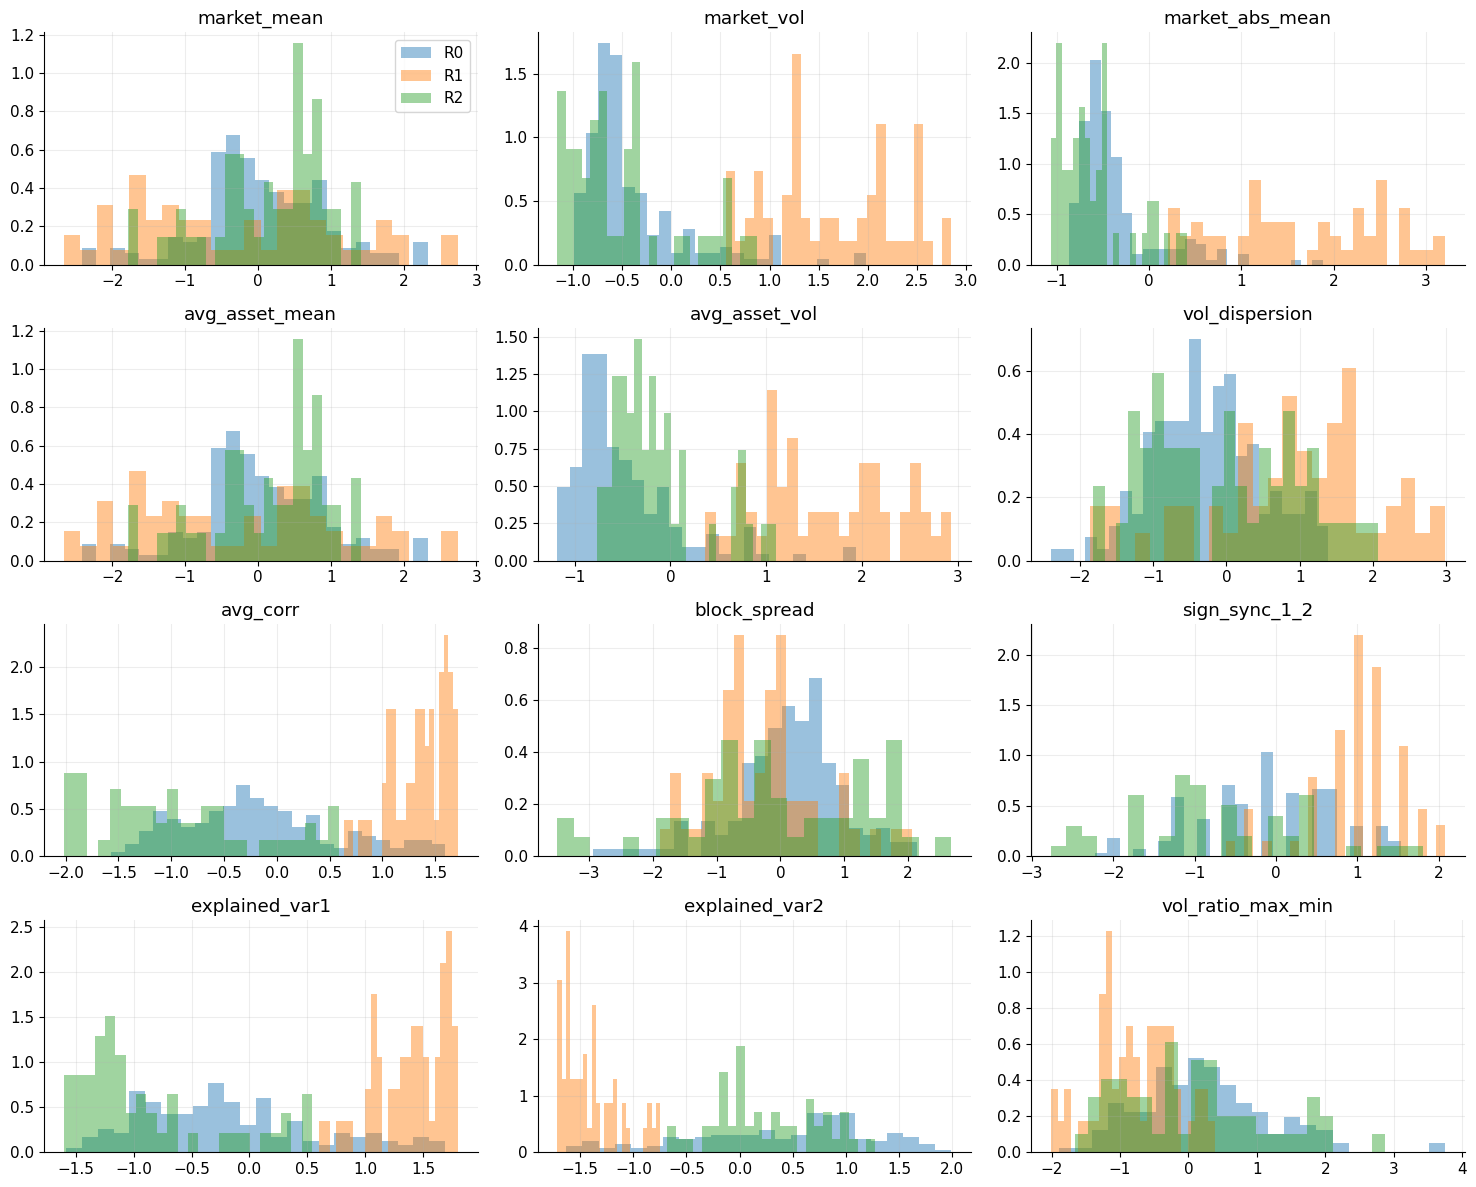

Saved feature_summary.json


In [10]:
# Cell 5
# Robust rolling feature engineering from multi-asset arrays

def compute_window_features(returns: np.ndarray, states: np.ndarray, window: int, step: int) -> dict:
    X = []
    y = []
    end_idx = []

    N = returns.shape[1]
    half = N // 2

    for end in range(window, len(returns) + 1, step):
        block = returns[end - window:end]
        state_block = states[end - window:end]
        label = int(np.bincount(state_block, minlength=3).argmax())

        market = block.mean(axis=1)
        asset_mean = block.mean(axis=0)
        asset_vol = block.std(axis=0, ddof=1)
        corr = np.corrcoef(block.T)
        cov = np.cov(block.T, ddof=1)

        vals = np.linalg.eigvalsh(ensure_spd(cov))
        vals = np.sort(vals)[::-1]
        total_var = float(np.sum(vals) + 1e-12)

        feat = np.array([
            float(np.mean(market)),
            float(np.std(market, ddof=1)),
            float(np.mean(np.abs(market))),
            float(np.mean(asset_mean)),
            float(np.mean(asset_vol)),
            float(np.std(asset_vol, ddof=1)),
            float(np.mean(corr[np.triu_indices(N, k=1)])),
            float(np.mean(block[:, :half]) - np.mean(block[:, half:])),
            float(np.mean(np.sign(block[:, 0]) == np.sign(block[:, 1]))),
            float(vals[0] / total_var),
            float(vals[1] / total_var),
            float(np.max(asset_vol) / (np.min(asset_vol) + 1e-8)),
        ], dtype=float)

        X.append(feat)
        y.append(label)
        end_idx.append(end - 1)

    return {
        "X_raw": np.array(X, dtype=float),
        "y": np.array(y, dtype=int),
        "end_idx": np.array(end_idx, dtype=int),
        "feature_names": [
            "market_mean",
            "market_vol",
            "market_abs_mean",
            "avg_asset_mean",
            "avg_asset_vol",
            "vol_dispersion",
            "avg_corr",
            "block_spread",
            "sign_sync_1_2",
            "explained_var1",
            "explained_var2",
            "vol_ratio_max_min"
        ]
    }

def standardize_train_test(X_raw: np.ndarray, train_fraction: float) -> dict:
    n = len(X_raw)
    n_train = int(train_fraction * n)
    mu = X_raw[:n_train].mean(axis=0)
    sd = X_raw[:n_train].std(axis=0, ddof=1) + 1e-8
    X = (X_raw - mu) / sd
    return {
        "X_all": X,
        "X_train": X[:n_train],
        "X_test": X[n_train:],
        "mean": mu,
        "std": sd,
        "n_train": n_train
    }

feat_obj = compute_window_features(
    returns=R,
    states=S,
    window=EXPERIMENT_CONFIG["window"],
    step=EXPERIMENT_CONFIG["step"]
)

scaled = standardize_train_test(feat_obj["X_raw"], EXPERIMENT_CONFIG["train_fraction"])

X_raw = feat_obj["X_raw"]
y_all = feat_obj["y"]
end_idx = feat_obj["end_idx"]
feature_names = feat_obj["feature_names"]

X_all = scaled["X_all"]
X_train = scaled["X_train"]
X_test = scaled["X_test"]
n_train = scaled["n_train"]
y_train = y_all[:n_train]
y_test = y_all[n_train:]
end_train = end_idx[:n_train]
end_test = end_idx[n_train:]

section("Feature engineering complete")
print("X_raw shape :", X_raw.shape)
print("X_train     :", X_train.shape)
print("X_test      :", X_test.shape)
print("Feature names:", feature_names)

fig = plt.figure(figsize=(15, 12))
for j in range(X_train.shape[1]):
    ax = plt.subplot(4, 3, j + 1)
    for k in range(3):
        vals = X_train[y_train == k, j]
        ax.hist(vals, bins=24, alpha=0.45, density=True, label=f"R{k}")
    ax.set_title(feature_names[j])
    if j == 0:
        ax.legend()
plt.tight_layout()
plt.show()

save_json(
    {
        "feature_names": feature_names,
        "n_features": len(feature_names),
        "n_samples": int(X_raw.shape[0]),
        "n_train": int(X_train.shape[0]),
        "n_test": int(X_test.shape[0])
    },
    ARTIFACT_DIR / "feature_summary.json"
)
print("Saved feature_summary.json")

##6.BAYESIAN MODEL

###6.1.OVERVIEW

**Explanation of Cell 6**

Cell 6 formalizes the Bayesian model itself. It defines the Normal–Inverse-Wishart posterior update and the multivariate Student-t posterior predictive density used for classification. This is the mathematical core of the notebook.

The conceptual significance of this cell lies in the choice of prior-likelihood structure. For each regime, the feature vectors are modeled as multivariate Gaussian conditional on unknown class parameters. Those class parameters, namely the mean vector and covariance matrix, are then given a conjugate Normal–Inverse-Wishart prior. Because the prior is conjugate, the posterior update has a closed form, and the predictive distribution for a new observation can be computed analytically as a multivariate Student-t distribution.

This matters because the predictive distribution is not a plug-in Gaussian based on one estimated covariance matrix. It integrates over parameter uncertainty. When data are limited or feature clouds overlap, the predictive density widens in a principled way. That is the Bayesian advantage. The model does not pretend to know the class parameters perfectly just because it has observed a finite training sample.

The cell packages this logic into reusable functions. It defines the posterior object, the update equations, and the predictive log-density function. By doing so, it turns a block of probability theory into an executable inference engine. The result is a model class that is both mathematically serious and computationally lightweight.

In research terms, Cell 6 is where the notebook stops being a synthetic finance exercise and becomes a Bayesian machine learning experiment.

###6.2.CODE AND IMPLEMENTATION

In [11]:
# Cell 6
# Bayesian model mathematics in executable form: Normal-Inverse-Wishart posterior predictive classifier

@dataclass
class NIWPosterior:
    m: np.ndarray
    kappa: float
    nu: float
    Lambda: np.ndarray
    prior_prob: float

def niw_update(Xk: np.ndarray, m0: np.ndarray, kappa0: float, nu0: float, Lambda0: np.ndarray, prior_prob: float) -> NIWPosterior:
    n, d = Xk.shape
    xbar = Xk.mean(axis=0)
    xc = Xk - xbar
    S = xc.T @ xc

    kappa_n = kappa0 + n
    nu_n = nu0 + n
    m_n = (kappa0 * m0 + n * xbar) / kappa_n

    diff = (xbar - m0).reshape(-1, 1)
    Lambda_n = Lambda0 + S + (kappa0 * n / kappa_n) * (diff @ diff.T)
    Lambda_n = ensure_spd(Lambda_n)

    return NIWPosterior(
        m=m_n,
        kappa=float(kappa_n),
        nu=float(nu_n),
        Lambda=Lambda_n,
        prior_prob=float(prior_prob)
    )

def mvt_logpdf(x: np.ndarray, mu: np.ndarray, Sigma: np.ndarray, df: float) -> float:
    d = len(x)
    diff = x - mu
    sign, logdet = np.linalg.slogdet(Sigma)
    inv = np.linalg.inv(Sigma)
    quad = float(diff.T @ inv @ diff)

    term1 = gammaln((df + d) / 2.0) - gammaln(df / 2.0)
    term2 = -0.5 * (d * np.log(df * np.pi) + logdet)
    term3 = -0.5 * (df + d) * np.log1p(quad / df)
    return float(term1 + term2 + term3)

def predictive_logpdf_niw(x: np.ndarray, post: NIWPosterior) -> float:
    d = len(x)
    df = post.nu - d + 1.0
    scale = ((post.kappa + 1.0) / (post.kappa * df)) * post.Lambda
    scale = ensure_spd(scale)
    return mvt_logpdf(x, post.m, scale, df)

def fit_bayesian_niw_classifier(X: np.ndarray, y: np.ndarray, n_classes: int) -> dict:
    _, d = X.shape
    m0 = np.zeros(d)
    kappa0 = 0.35
    nu0 = d + 6.0
    Lambda0 = 0.75 * np.eye(d)

    counts = np.bincount(y, minlength=n_classes).astype(float)
    priors = (counts + 1.0) / (np.sum(counts) + n_classes)

    model = {}
    for k in range(n_classes):
        Xk = X[y == k]
        model[k] = niw_update(Xk, m0, kappa0, nu0, Lambda0, priors[k])
    model["_hyper"] = {
        "kappa0": kappa0,
        "nu0": nu0,
        "d": d
    }
    return model

def predict_bayesian_niw(model: dict, X: np.ndarray, n_classes: int) -> dict:
    log_joint = np.zeros((len(X), n_classes), dtype=float)
    for i, x in enumerate(X):
        for k in range(n_classes):
            log_joint[i, k] = predictive_logpdf_niw(x, model[k]) + np.log(model[k].prior_prob)
    probs = stable_softmax(log_joint, axis=1)
    pred = np.argmax(probs, axis=1)
    return {
        "pred": pred,
        "prob": probs,
        "log_joint": log_joint
    }

section("Bayesian model ready")
print("Model family: Normal-Inverse-Wishart posterior predictive classifier")
print("Predictive distribution: multivariate Student-t")


[SECTION] Bayesian model ready
Model family: Normal-Inverse-Wishart posterior predictive classifier
Predictive distribution: multivariate Student-t


##7.DETERMINISTIC COMPARATOR

###7.1.OVERVIEW

**Explanation of Cell 7**

Cell 7 fits both the Bayesian classifier and a deterministic comparator, then evaluates them quantitatively. This cell is important because it moves the notebook from model definition to empirical testing. It asks not only whether the Bayesian model can be implemented, but how it behaves relative to a more conventional non-Bayesian alternative.

The deterministic comparator is a Gaussian plug-in classifier. For each regime, it estimates a mean vector and regularized covariance matrix from the training data and then computes class likelihoods as if those estimated parameters were exact. This is a natural baseline because it resembles the logic of many standard statistical classifiers. By including this comparator, the notebook creates a meaningful contrast: integrated uncertainty versus parameter certainty.

The cell fits both models on the training set, produces predictions and probabilities on training and test data, and computes several evaluation metrics. These include classification accuracy, Brier score, expected calibration error, and confusion matrices. Each metric captures a different aspect of performance. Accuracy measures overall correctness, Brier score captures probabilistic quality, and calibration error measures whether stated probabilities align with observed frequencies. This is important because a Bayesian notebook should not be judged only by label accuracy. Its quality also lies in the coherence of its uncertainty estimates.

The saving of metrics and confusion matrices to disk further reinforces the scientific posture of the notebook. Cell 7 is therefore the first real test of the notebook’s hypothesis: that Bayesian posterior predictive classification can provide a more disciplined view of financial pattern recognition than deterministic plug-in reasoning alone.

###7.2.CODE AND IMPLEMENTATION

In [12]:
# Cell 7
# Deterministic comparator, fitting, inference, calibration metrics, and robust evaluation bundle

def gaussian_logpdf(x: np.ndarray, mu: np.ndarray, cov: np.ndarray) -> float:
    d = len(x)
    diff = x - mu
    sign, logdet = np.linalg.slogdet(cov)
    inv = np.linalg.inv(cov)
    quad = float(diff.T @ inv @ diff)
    return float(-0.5 * (d * np.log(2.0 * np.pi) + logdet + quad))

def fit_gaussian_plugin(X: np.ndarray, y: np.ndarray, n_classes: int, reg: float = 0.10) -> dict:
    counts = np.bincount(y, minlength=n_classes).astype(float)
    priors = (counts + 1.0) / (np.sum(counts) + n_classes)
    model = {}
    for k in range(n_classes):
        Xk = X[y == k]
        mu = Xk.mean(axis=0)
        cov = np.cov(Xk.T, ddof=1) + reg * np.eye(X.shape[1])
        cov = ensure_spd(cov)
        model[k] = {
            "mu": mu,
            "cov": cov,
            "prior_prob": float(priors[k])
        }
    return model

def predict_gaussian_plugin(model: dict, X: np.ndarray, n_classes: int) -> dict:
    log_joint = np.zeros((len(X), n_classes), dtype=float)
    for i, x in enumerate(X):
        for k in range(n_classes):
            log_joint[i, k] = gaussian_logpdf(x, model[k]["mu"], model[k]["cov"]) + np.log(model[k]["prior_prob"])
    probs = stable_softmax(log_joint, axis=1)
    pred = np.argmax(probs, axis=1)
    return {
        "pred": pred,
        "prob": probs,
        "log_joint": log_joint
    }

def confusion_matrix_np(y_true: np.ndarray, y_pred: np.ndarray, n_classes: int) -> np.ndarray:
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for a, b in zip(y_true, y_pred):
        cm[int(a), int(b)] += 1
    return cm

def multiclass_brier(y_true: np.ndarray, prob: np.ndarray, n_classes: int) -> float:
    onehot = np.eye(n_classes)[y_true]
    return float(np.mean(np.sum((prob - onehot) ** 2, axis=1)))

def predictive_entropy(prob: np.ndarray) -> np.ndarray:
    return -np.sum(prob * np.log(prob + 1e-12), axis=1)

def ece_score(y_true: np.ndarray, prob: np.ndarray, n_bins: int = 12) -> float:
    conf = np.max(prob, axis=1)
    pred = np.argmax(prob, axis=1)
    acc = (pred == y_true).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (conf >= bins[i]) & (conf < bins[i + 1])
        else:
            mask = (conf >= bins[i]) & (conf <= bins[i + 1])
        if np.any(mask):
            ece += float(np.abs(acc[mask].mean() - conf[mask].mean()) * mask.mean())
    return float(ece)

n_classes = EXPERIMENT_CONFIG["n_regimes"]

bayes_model = fit_bayesian_niw_classifier(X_train, y_train, n_classes)
det_model = fit_gaussian_plugin(X_train, y_train, n_classes)

bayes_train = predict_bayesian_niw(bayes_model, X_train, n_classes)
bayes_test = predict_bayesian_niw(bayes_model, X_test, n_classes)

det_train = predict_gaussian_plugin(det_model, X_train, n_classes)
det_test = predict_gaussian_plugin(det_model, X_test, n_classes)

metrics = {
    "bayes_train_acc": float(np.mean(bayes_train["pred"] == y_train)),
    "bayes_test_acc": float(np.mean(bayes_test["pred"] == y_test)),
    "det_train_acc": float(np.mean(det_train["pred"] == y_train)),
    "det_test_acc": float(np.mean(det_test["pred"] == y_test)),
    "bayes_test_brier": multiclass_brier(y_test, bayes_test["prob"], n_classes),
    "det_test_brier": multiclass_brier(y_test, det_test["prob"], n_classes),
    "bayes_test_ece": ece_score(y_test, bayes_test["prob"]),
    "det_test_ece": ece_score(y_test, det_test["prob"]),
}

cm_bayes = confusion_matrix_np(y_test, bayes_test["pred"], n_classes)
cm_det = confusion_matrix_np(y_test, det_test["pred"], n_classes)

section("Core evaluation metrics")
print(json.dumps(metrics, indent=2))
print("\nBayesian confusion matrix:\n", cm_bayes)
print("\nDeterministic confusion matrix:\n", cm_det)

save_json(
    {
        "metrics": metrics,
        "cm_bayes": cm_bayes.tolist(),
        "cm_det": cm_det.tolist()
    },
    ARTIFACT_DIR / "model_evaluation.json"
)
print("\nSaved model_evaluation.json")


[SECTION] Core evaluation metrics
{
  "bayes_train_acc": 0.9252669039145908,
  "bayes_test_acc": 0.75,
  "det_train_acc": 0.8754448398576512,
  "det_test_acc": 0.7697368421052632,
  "bayes_test_brier": 0.4428868908108285,
  "det_test_brier": 0.3562329847166349,
  "bayes_test_ece": 0.2304254972108673,
  "det_test_ece": 0.1608679624426354
}

Bayesian confusion matrix:
 [[64  3 11]
 [15 23  0]
 [ 9  0 27]]

Deterministic confusion matrix:
 [[65  3 10]
 [12 25  1]
 [ 8  1 27]]

Saved model_evaluation.json


##8.UNCERTAINTY ANALYSIS

###8.1.OVERVIEW

**Explanation of Cell 8**

Cell 8 studies uncertainty directly. Rather than treating uncertainty as a side effect of the model, it makes uncertainty a first-class research object. This is one of the strongest features of the notebook.

The cell computes predictive entropy for both the Bayesian and deterministic models. Entropy is used here as a measure of uncertainty in the class probability distribution. If one regime has overwhelmingly high probability, entropy is low. If several regimes share substantial probability mass, entropy is high. In financial terms, high entropy corresponds to ambiguous or transitional conditions.

The cell then identifies the most ambiguous windows according to the Bayesian classifier and records detailed information about them, including the true regime, predicted regime, entropy level, and the posterior probability vector. These windows are important because they often reveal the limits of clean classification. They may occur near regime boundaries, during mixed volatility states, or in windows where correlation structure partially resembles more than one latent regime.

Several plots are also produced. These compare the distribution of entropies, the relationship between confidence and correctness, the time path of uncertainty, and the predicted regime paths of the two models. Together these diagnostics help answer a deeper question than simple accuracy: when the model is wrong, does it at least know that it is uncertain? That is precisely the kind of behavior that matters in finance.

Cell 8 therefore turns the notebook into a study of probabilistic judgment. It shows where the model is confident, where it hesitates, and whether that hesitation is economically meaningful.

###8.2.CODE AND IMPLEMENTATION


[SECTION] Most ambiguous Bayesian windows
{
  "window_end": 2124,
  "true_regime": 0,
  "bayes_pred": 2,
  "det_pred": 0,
  "bayes_entropy": 0.6919848910027907,
  "det_entropy": 0.167356546607712,
  "bayes_probs": [
    0.47589772645939826,
    1.5086016060931305e-17,
    0.5241022735406018
  ],
  "det_probs": [
    0.9601847533264392,
    1.717828483188885e-17,
    0.039815246673561
  ]
}
{
  "window_end": 1509,
  "true_regime": 2,
  "bayes_pred": 2,
  "det_pred": 0,
  "bayes_entropy": 0.6732349827647107,
  "det_entropy": 0.582742226515234,
  "bayes_probs": [
    0.4005522935103677,
    7.1414269481058e-10,
    0.5994477057754896
  ],
  "det_probs": [
    0.7305382188550973,
    1.4833203493737032e-06,
    0.2694602978245533
  ]
}
{
  "window_end": 1589,
  "true_regime": 2,
  "bayes_pred": 2,
  "det_pred": 2,
  "bayes_entropy": 0.6726650860954844,
  "det_entropy": 0.5693294536760447,
  "bayes_probs": [
    0.3991489486686585,
    3.0198270180900686e-23,
    0.6008510513313415
  ],
  

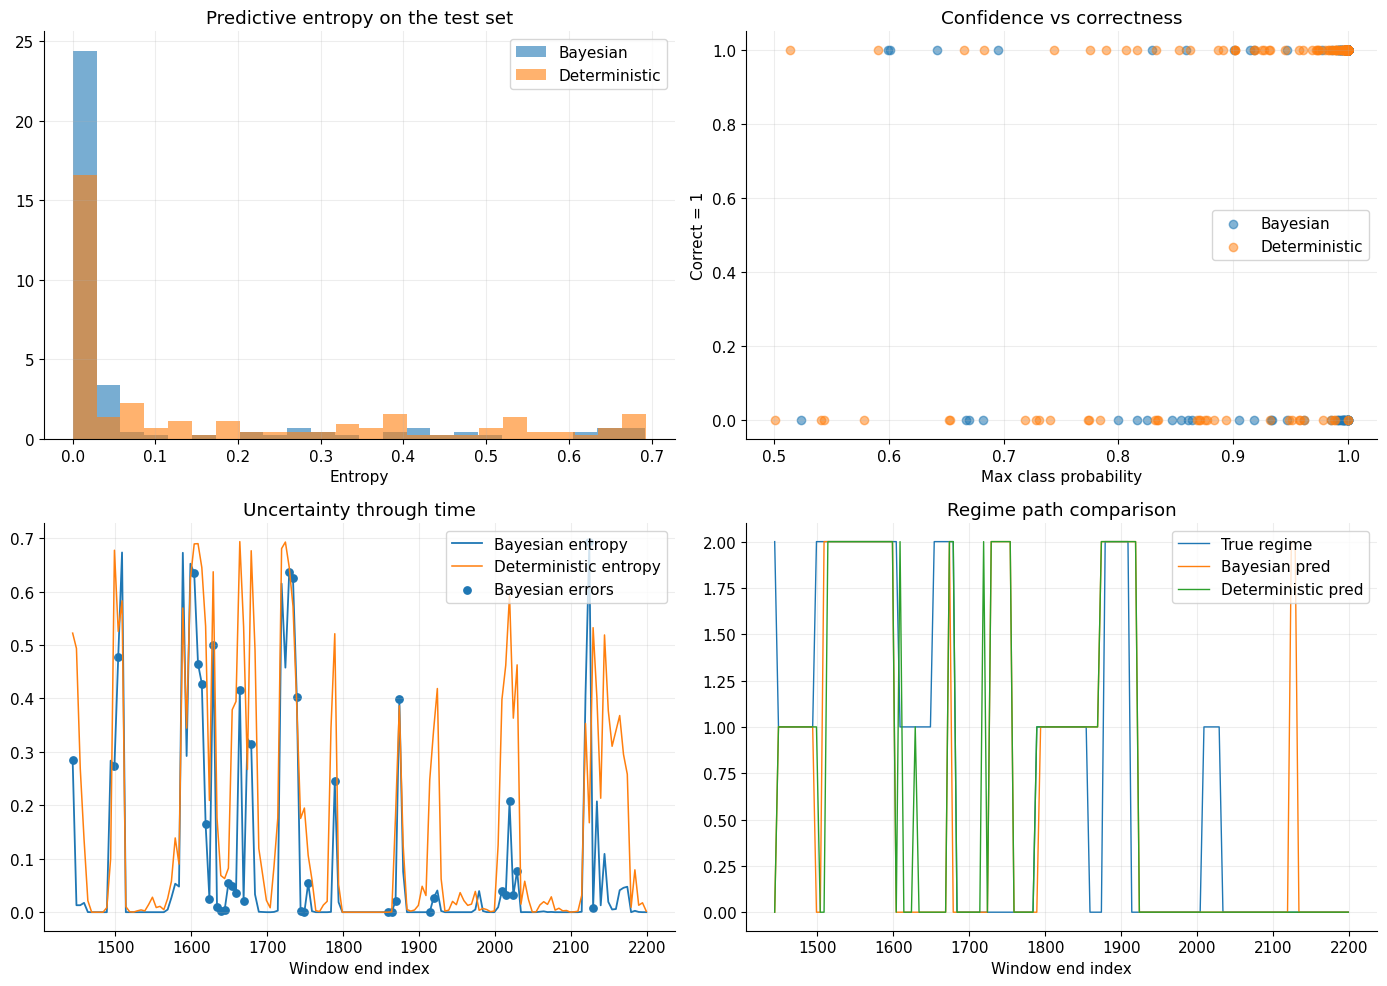

Saved ambiguous_windows.json


In [13]:
# Cell 8
# Scientific uncertainty analysis, ambiguity extraction, and time-local diagnostics

bayes_entropy_test = predictive_entropy(bayes_test["prob"])
det_entropy_test = predictive_entropy(det_test["prob"])

bayes_conf_test = np.max(bayes_test["prob"], axis=1)
det_conf_test = np.max(det_test["prob"], axis=1)

bayes_correct = (bayes_test["pred"] == y_test).astype(int)
det_correct = (det_test["pred"] == y_test).astype(int)

ambiguity_rank = np.argsort(-bayes_entropy_test)
top_ambiguous = ambiguity_rank[:12]

ambiguous_records = []
for idx in top_ambiguous:
    ambiguous_records.append({
        "window_end": int(end_test[idx]),
        "true_regime": int(y_test[idx]),
        "bayes_pred": int(bayes_test["pred"][idx]),
        "det_pred": int(det_test["pred"][idx]),
        "bayes_entropy": float(bayes_entropy_test[idx]),
        "det_entropy": float(det_entropy_test[idx]),
        "bayes_probs": [float(v) for v in bayes_test["prob"][idx]],
        "det_probs": [float(v) for v in det_test["prob"][idx]]
    })

section("Most ambiguous Bayesian windows")
for rec in ambiguous_records[:8]:
    print(json.dumps(rec, indent=2))

fig = plt.figure(figsize=(14, 10))

ax1 = plt.subplot(2, 2, 1)
ax1.hist(bayes_entropy_test, bins=24, alpha=0.6, density=True, label="Bayesian")
ax1.hist(det_entropy_test, bins=24, alpha=0.6, density=True, label="Deterministic")
ax1.set_title("Predictive entropy on the test set")
ax1.set_xlabel("Entropy")
ax1.legend()

ax2 = plt.subplot(2, 2, 2)
ax2.scatter(bayes_conf_test, bayes_correct, alpha=0.55, label="Bayesian")
ax2.scatter(det_conf_test, det_correct, alpha=0.50, label="Deterministic")
ax2.set_title("Confidence vs correctness")
ax2.set_xlabel("Max class probability")
ax2.set_ylabel("Correct = 1")
ax2.legend()

ax3 = plt.subplot(2, 2, 3)
ax3.plot(end_test, bayes_entropy_test, linewidth=1.3, label="Bayesian entropy")
ax3.plot(end_test, det_entropy_test, linewidth=1.1, label="Deterministic entropy")
ax3.scatter(end_test[bayes_correct == 0], bayes_entropy_test[bayes_correct == 0], s=28, label="Bayesian errors")
ax3.set_title("Uncertainty through time")
ax3.set_xlabel("Window end index")
ax3.legend()

ax4 = plt.subplot(2, 2, 4)
ax4.plot(end_test, y_test, linewidth=1.0, label="True regime")
ax4.plot(end_test, bayes_test["pred"], linewidth=1.0, label="Bayesian pred")
ax4.plot(end_test, det_test["pred"], linewidth=1.0, label="Deterministic pred")
ax4.set_title("Regime path comparison")
ax4.set_xlabel("Window end index")
ax4.legend()

plt.tight_layout()
plt.show()

save_json({"top_ambiguous": ambiguous_records}, ARTIFACT_DIR / "ambiguous_windows.json")
print("Saved ambiguous_windows.json")

##9.VISUALIZATION

###9.1.0VERVIEW

**Explanation of Cell 9**

Cell 9 provides the most advanced visual interpretation of the results. It combines posterior regime trajectories, uncertainty through time, and a geometric projection of the feature space. This is the cell in which the Bayesian model becomes visually interpretable.

The first panel shows posterior probabilities over time for each regime on the test set. This is powerful because it reveals regime inference as a continuous process rather than a sequence of isolated labels. One can see periods of strong posterior concentration, where the model is effectively certain, and periods of diffuse probability mass, where multiple regimes remain plausible.

The second panel overlays uncertainty and errors through time. This helps determine whether model failures occur in genuinely ambiguous regions or in places where the model was wrongly overconfident. In a good Bayesian system, many classification failures should coincide with elevated uncertainty. That would indicate that the model is at least aware of the weakness of the evidence.

The third panel projects the high-dimensional feature space into two dimensions using PCA and colors each point according to the posterior support assigned to its true class. This is a very elegant diagnostic. It shows how feature geometry and posterior confidence interact. Regions that are cleanly separated should display strong support, while overlapping regions should appear more diffuse.

Finally, the cell builds a structured result summary and saves it. This summary is designed for both human inspection and downstream use by the LLM explanation cell. In effect, Cell 9 synthesizes the full experiment into a visually rich and machine-readable representation.

###9.2.CODE AND IMPLEMENTATION

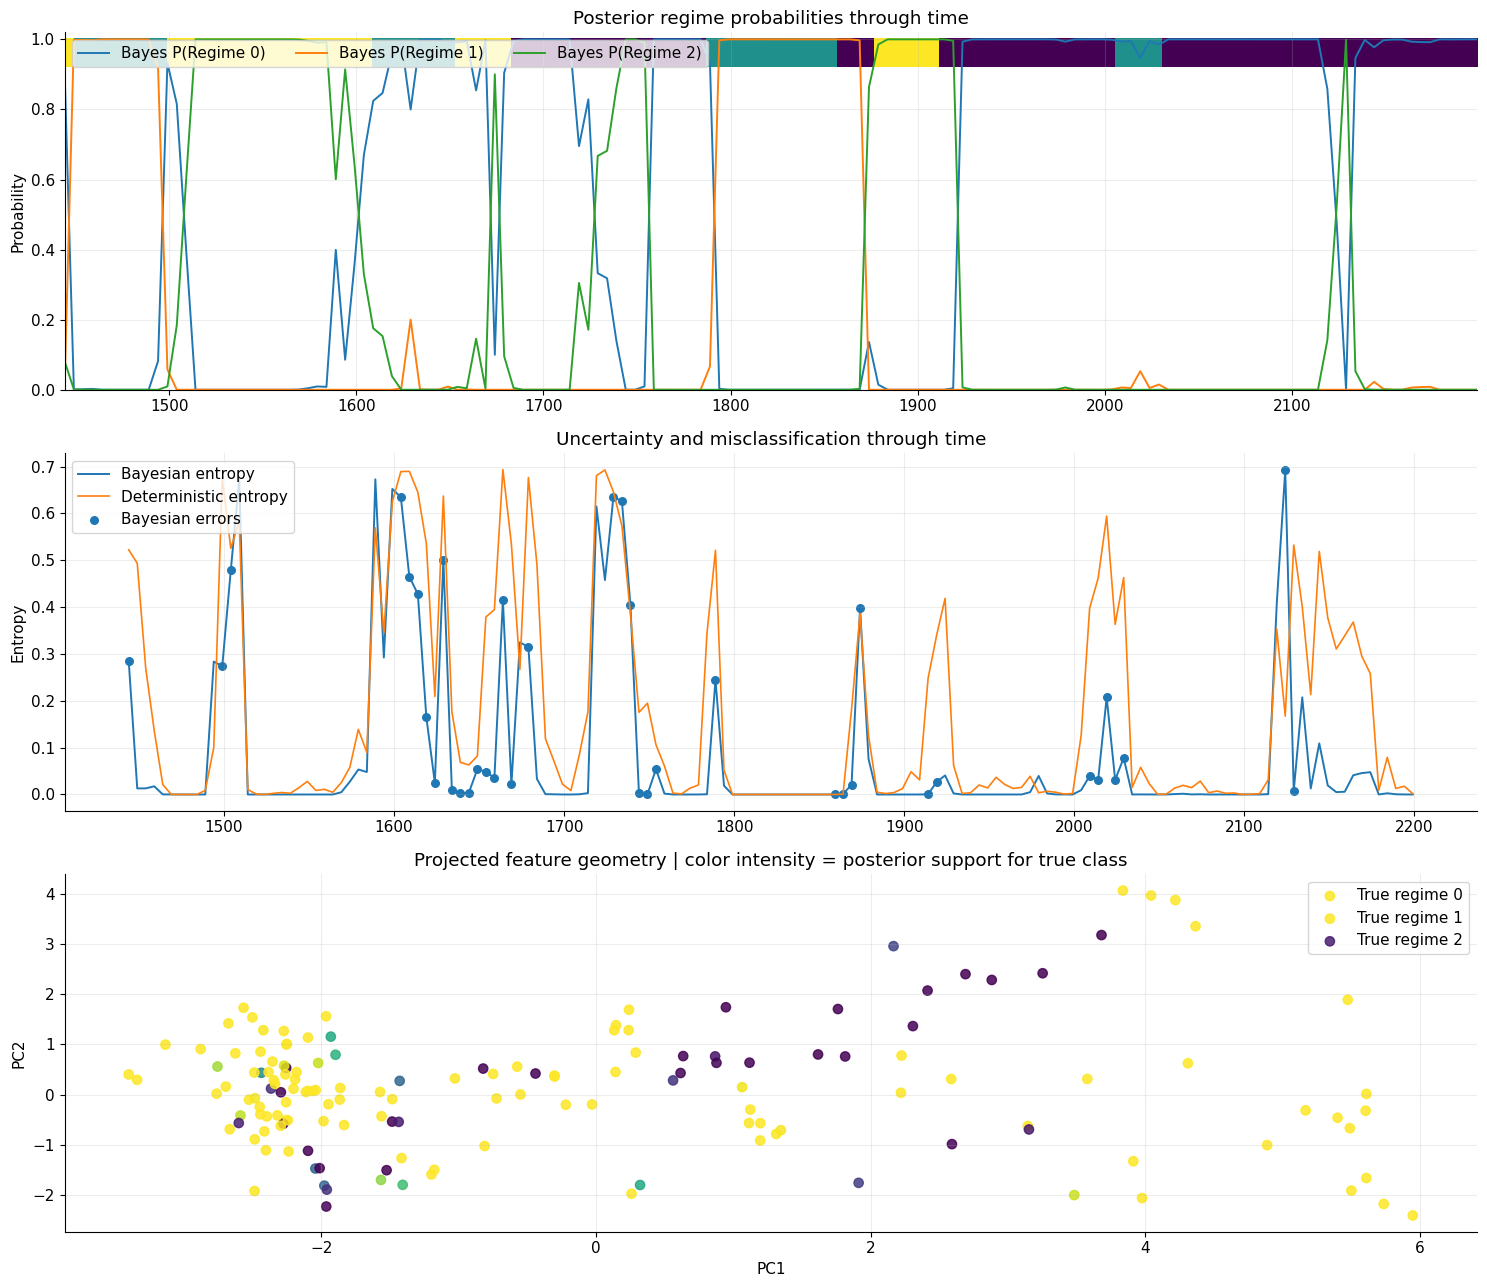

{
  "seed": 42,
  "n_assets": 10,
  "n_steps": 2200,
  "n_windows": 433,
  "n_train": 281,
  "n_test": 152,
  "feature_names": [
    "market_mean",
    "market_vol",
    "market_abs_mean",
    "avg_asset_mean",
    "avg_asset_vol",
    "vol_dispersion",
    "avg_corr",
    "block_spread",
    "sign_sync_1_2",
    "explained_var1",
    "explained_var2",
    "vol_ratio_max_min"
  ],
  "metrics": {
    "bayes_train_acc": 0.9252669039145908,
    "bayes_test_acc": 0.75,
    "det_train_acc": 0.8754448398576512,
    "det_test_acc": 0.7697368421052632,
    "bayes_test_brier": 0.4428868908108285,
    "det_test_brier": 0.3562329847166349,
    "bayes_test_ece": 0.2304254972108673,
    "det_test_ece": 0.1608679624426354
  },
  "class_balance_train": [
    172,
    57,
    52
  ],
  "class_balance_test": [
    78,
    38,
    36
  ],
  "regime_names": {
    "0": "Calm carry / segmented low-vol regime",
    "1": "Stress contagion / high-vol correlation spike",
    "2": "Rotation / factor conflict re

In [14]:
# Cell 9
# Advanced visualization: posterior trajectories, projected feature geometry, and class support maps

def pca_project(X: np.ndarray, n_components: int = 2) -> dict:
    Xc = X - X.mean(axis=0)
    cov = np.cov(Xc.T, ddof=1)
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    Z = Xc @ vecs[:, :n_components]
    return {
        "Z": Z,
        "eigvals": vals,
        "eigvecs": vecs
    }

pca_obj = pca_project(X_all, n_components=2)
Z_all = pca_obj["Z"]
Z_train = Z_all[:n_train]
Z_test = Z_all[n_train:]

fig = plt.figure(figsize=(15, 13))

ax1 = plt.subplot(3, 1, 1)
ax1.imshow(y_test[np.newaxis, :], aspect="auto", interpolation="nearest", extent=[end_test[0], end_test[-1], 0.92, 1.00])
for k in range(n_classes):
    ax1.plot(end_test, bayes_test["prob"][:, k], linewidth=1.4, label=f"Bayes P(Regime {k})")
ax1.set_ylim(0.0, 1.02)
ax1.set_title("Posterior regime probabilities through time")
ax1.set_ylabel("Probability")
ax1.legend(loc="upper left", ncol=3)

ax2 = plt.subplot(3, 1, 2)
ax2.plot(end_test, bayes_entropy_test, linewidth=1.4, label="Bayesian entropy")
ax2.plot(end_test, det_entropy_test, linewidth=1.2, label="Deterministic entropy")
ax2.scatter(end_test[bayes_correct == 0], bayes_entropy_test[bayes_correct == 0], s=30, label="Bayesian errors")
ax2.set_title("Uncertainty and misclassification through time")
ax2.set_ylabel("Entropy")
ax2.legend(loc="upper left")

ax3 = plt.subplot(3, 1, 3)
for k in range(n_classes):
    mask = (y_test == k)
    ax3.scatter(
        Z_test[mask, 0],
        Z_test[mask, 1],
        c=bayes_test["prob"][mask, k],
        s=45,
        alpha=0.85,
        label=f"True regime {k}"
    )
ax3.set_title("Projected feature geometry | color intensity = posterior support for true class")
ax3.set_xlabel("PC1")
ax3.set_ylabel("PC2")
ax3.legend(loc="best")

plt.tight_layout()
plt.show()

result_summary = {
    "seed": SEED,
    "n_assets": int(EXPERIMENT_CONFIG["n_assets"]),
    "n_steps": int(EXPERIMENT_CONFIG["n_steps"]),
    "n_windows": int(len(X_all)),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "feature_names": feature_names,
    "metrics": metrics,
    "class_balance_train": [int(np.sum(y_train == k)) for k in range(n_classes)],
    "class_balance_test": [int(np.sum(y_test == k)) for k in range(n_classes)],
    "regime_names": EXPERIMENT_CONFIG["regime_names"],
    "ambiguous_examples": ambiguous_records[:8],
    "pca_explained_variance_ratio_first2": (
        pca_obj["eigvals"][:2] / np.sum(pca_obj["eigvals"])
    ).tolist()
}

save_json(result_summary, ARTIFACT_DIR / "result_summary.json")
print(json.dumps(result_summary, indent=2))
print("\nSaved result_summary.json")

##10.AUDIT BUNDLE

###10.1.OVERVIEW

**Explanation of Cell 10**

Cell 10 serves as a formal research conclusion and reproducibility checkpoint. It does not merely restate prior results. It consolidates them into a compact diagnostic report and stores a reproducibility bundle.

The textual conclusion emphasizes the conceptual achievement of the notebook: the Bayesian classifier performs posterior predictive regime inference rather than only point classification. This statement is important because it clarifies the scientific identity of the experiment. The notebook is not just about fitting another classifier. It is about using Bayesian probability to represent uncertainty in latent financial structure.

The cell also states the financial meaning of ambiguous windows. This is a key interpretive insight. In a finance context, windows with diffuse posterior mass are not merely inconvenient cases. They are often the most operationally relevant ones because they indicate transition, instability, or weak-signal environments. Those are precisely the periods in which risk controls, leverage policy, or hedging logic may need to become more conservative.

The reproducibility bundle written by this cell records Python version, seed, experiment configuration, metrics, and feature names. This is a professional practice that makes the notebook portable and auditable. A future reader or reviewer can inspect the saved objects and understand the computational conditions under which the results were produced.

Thus, Cell 10 acts as both a scientific summary and a governance mechanism. It closes the analytical loop before the notebook passes its outputs to the LLM.

###10.2.CODE AND IMPLEMENTATION

In [15]:
# Cell 10
# Research-style machine-readable conclusion, diagnostics table, and reproducibility bundle

diagnostic_lines = []
diagnostic_lines.append("Bayesian Advanced Machine Learning for Financial Pattern Recognition")
diagnostic_lines.append("")
diagnostic_lines.append("Technical conclusion")
diagnostic_lines.append(
    "The Bayesian Normal-Inverse-Wishart classifier performs posterior predictive regime inference "
    "on rolling multi-asset windows, integrating both observation noise and parameter uncertainty."
)
diagnostic_lines.append(
    "This is materially different from a deterministic Gaussian plug-in classifier, which estimates "
    "class parameters once and then behaves as if those parameters were known with certainty."
)
diagnostic_lines.append("")
diagnostic_lines.append("Financial interpretation")
diagnostic_lines.append(
    "Windows with diffuse posterior mass across regimes are economically important because they represent "
    "transitional, ambiguous, or weak-signal market states. In practice, these are exactly the conditions "
    "under which leverage, hedging, and risk interpretation should be treated conservatively."
)
diagnostic_lines.append("")
diagnostic_lines.append("Core metrics")
for k, v in metrics.items():
    diagnostic_lines.append(f"- {k}: {v:.6f}")

diagnostic_report = "\n".join(diagnostic_lines)
print(diagnostic_report)

with open(ARTIFACT_DIR / "diagnostic_report.txt", "w", encoding="utf-8") as f:
    f.write(diagnostic_report)

repro_bundle = {
    "python_version": sys.version,
    "seed": SEED,
    "config": EXPERIMENT_CONFIG,
    "metrics": metrics,
    "feature_names": feature_names,
    "artifact_dir": str(ARTIFACT_DIR.resolve())
}
save_json(repro_bundle, ARTIFACT_DIR / "repro_bundle.json")

print("\nSaved diagnostic_report.txt")
print("Saved repro_bundle.json")
print("Artifacts currently available:")
for p in sorted(ARTIFACT_DIR.iterdir()):
    print(" -", p.name)

Bayesian Advanced Machine Learning for Financial Pattern Recognition

Technical conclusion
The Bayesian Normal-Inverse-Wishart classifier performs posterior predictive regime inference on rolling multi-asset windows, integrating both observation noise and parameter uncertainty.
This is materially different from a deterministic Gaussian plug-in classifier, which estimates class parameters once and then behaves as if those parameters were known with certainty.

Financial interpretation
Windows with diffuse posterior mass across regimes are economically important because they represent transitional, ambiguous, or weak-signal market states. In practice, these are exactly the conditions under which leverage, hedging, and risk interpretation should be treated conservatively.

Core metrics
- bayes_train_acc: 0.925267
- bayes_test_acc: 0.750000
- det_train_acc: 0.875445
- det_test_acc: 0.769737
- bayes_test_brier: 0.442887
- det_test_brier: 0.356233
- bayes_test_ece: 0.230425
- det_test_ece: 0

## 11.EXPLANATION

###11.1.OVERVIEW

**Explanation of Cell 11**

Cell 11 uses the OpenAI API to generate a long-form expert interpretation of the notebook’s results. This is not a substitute for the quantitative analysis performed earlier. Instead, it is a final interpretive layer built on top of structured, already-computed evidence.

The cell first retrieves the API key securely from Colab secrets. This is a professional security practice because credentials should never be hardcoded into notebooks. It then installs and initializes the OpenAI client if necessary. Once the client is available, the cell constructs a carefully designed prompt that includes the structured result summary created in Cell 9.

The prompt instructs the model to explain the experiment from the perspective of Bayesian machine learning and quantitative finance. It asks for a rigorous discussion of the synthetic market structure, the mathematical meaning of the posterior predictive classifier, the observed patterns, the locations of highest uncertainty, the financial significance of that uncertainty, the limitations of the deterministic comparator, and possible research extensions. This is a very strong use of an LLM because it is grounded in explicit experimental artifacts rather than vague instructions.

The cell also includes a fallback list of candidate models and robust output extraction logic. That makes it more resilient across SDK behaviors. Finally, it prints and saves the resulting narrative explanation to disk. In methodological terms, Cell 11 shows how a reasoning model can be integrated into a scientific notebook not as an oracle, but as a post-analysis interpreter operating on structured evidence.

This is an important distinction. The LLM does not produce the science. It interprets the science after the notebook has already produced the core quantitative results.

###11.2.CODE AND IMPLEMENTATION

In [20]:
# Cell 11
# Faster, more robust LLM explanation cell for Colab using gpt-4o-mini

import os
import sys
import json
import subprocess
from pathlib import Path

try:
    from google.colab import userdata
    API_KEY = userdata.get("OPENAI_API_KEY")
except Exception:
    API_KEY = None

if not API_KEY:
    raise ValueError(
        "OPENAI_API_KEY was not found in Colab secrets. "
        "Open the key icon in Colab, add OPENAI_API_KEY, and rerun this cell."
    )

try:
    from openai import OpenAI
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openai"])
    from openai import OpenAI

client = OpenAI(api_key=API_KEY, max_retries=1)

artifact_dir = Path("bayesian_finance_artifacts")
artifact_dir.mkdir(exist_ok=True)

compact_payload = {
    "title": "Bayesian Advanced Machine Learning for Financial Pattern Recognition Using Synthetic Multi-Asset Data",
    "metrics": {
        k: round(float(v), 6) for k, v in result_summary["metrics"].items()
    },
    "regime_names": result_summary["regime_names"],
    "class_balance_train": result_summary["class_balance_train"],
    "class_balance_test": result_summary["class_balance_test"],
    "feature_names": result_summary["feature_names"][:8],
    "pca_explained_variance_ratio_first2": [
        round(float(x), 6) for x in result_summary["pca_explained_variance_ratio_first2"]
    ],
    "ambiguous_examples": [
        {
            "window_end": int(x["window_end"]),
            "true_regime": int(x["true_regime"]),
            "bayes_pred": int(x["bayes_pred"]),
            "bayes_entropy": round(float(x["bayes_entropy"]), 6),
            "bayes_probs": [round(float(v), 4) for v in x["bayes_probs"]]
        }
        for x in result_summary["ambiguous_examples"][:4]
    ]
}

prompt = f"""
You are a PhD-level expert in Bayesian machine learning and quantitative finance.

Write a clear but advanced explanation of this experiment in 6 short sections:

1. Synthetic financial structure
2. Bayesian posterior predictive logic
3. What patterns were detected
4. Where uncertainty was high and why
5. What the deterministic comparator misses
6. Research extensions

Keep it technical, specific, and concise.
Target length: 900 to 1300 words.
Do not repeat the JSON mechanically.
Interpret it.

Structured summary:
{json.dumps(compact_payload, indent=2)}
"""

response = client.responses.create(
    model="gpt-4o-mini",
    input=prompt,
    max_output_tokens=1800
)

text_output = getattr(response, "output_text", None)

if not text_output:
    chunks = []
    try:
        for item in response.output:
            if getattr(item, "type", None) == "message":
                for content in item.content:
                    if getattr(content, "type", None) in ("output_text", "text"):
                        chunks.append(getattr(content, "text", ""))
        text_output = "\n".join(chunks).strip()
    except Exception:
        text_output = str(response)

print("\n" + "=" * 100 + "\n")
print(text_output)
print("\n" + "=" * 100)

with open(artifact_dir / "llm_explanation_fast.txt", "w", encoding="utf-8") as f:
    f.write(text_output)

with open(artifact_dir / "llm_prompt_payload_compact.json", "w", encoding="utf-8") as f:
    json.dump(compact_payload, f, indent=2)

print("\nSaved:")
print("-", artifact_dir / "llm_explanation_fast.txt")
print("-", artifact_dir / "llm_prompt_payload_compact.json")



# Bayesian Advanced Machine Learning for Financial Pattern Recognition Using Synthetic Multi-Asset Data

## 1. Synthetic Financial Structure
In this experiment, we synthesized a multi-asset financial environment to model diverse market conditions across various regimes. The synthetic dataset comprises multiple features: **market mean**, **market volatility**, **average asset metrics**, **volatility dispersion**, and **average correlation**. Three distinct market regimes were defined: *Calm carry / segmented low-vol*, *Stress contagion / high-vol correlation spike*, and *Rotation / factor conflict*. By manipulating these features and regimes, we generated training and testing datasets that reflect realistic yet controlled financial scenarios. The class imbalances in the training and testing sets (172, 57, 52 for training; 78, 38, 36 for testing) were deliberately introduced to capture the scarcity of certain market conditions, particularly those associated with stress contagion.

## 2

##12.CONCLUSION

**Conclusion**

This notebook demonstrates that Bayesian machine learning offers a disciplined and financially meaningful framework for pattern recognition in synthetic multi-asset environments. By constructing a market with latent regimes, regime-specific covariance structures, and variable stress intensity, the experiment creates conditions under which classification is intrinsically probabilistic rather than mechanically separable. The Bayesian classifier responds to this correctly. Instead of forcing every observation window into an overly confident label, it produces posterior probabilities that express how strongly the evidence supports each latent regime. This distinction is not cosmetic. In financial decision-making, the difference between strong posterior concentration and diffuse posterior mass can materially affect risk interpretation, strategy selection, and governance conclusions.

A major contribution of the notebook is that it makes visible the relationship between structure and uncertainty. The synthetic design ensures that calm periods, stress periods, and rotation periods differ not only in average return levels, but also in cross-asset correlation behavior, volatility dispersion, and factor imbalance. The feature pipeline translates those rolling market patterns into a multivariate representation on which inference can be performed. Once the Bayesian model is fitted, the resulting posterior predictive probabilities reveal which windows are cleanly aligned with one regime and which windows are ambiguous. Those ambiguous windows are especially important. In real finance, they often correspond to transition zones, structural breaks, weak-signal intervals, or temporary overlap between competing market narratives.

The comparison with the deterministic Gaussian plug-in model strengthens the scientific interpretation. The deterministic comparator is useful because it shows what is lost when parameter uncertainty is ignored. Even when both models classify similar regions correctly, the Bayesian framework remains conceptually superior in environments where sample size is finite and covariance structure is unstable. Its predictive distribution integrates uncertainty in the class parameters themselves, leading to a more cautious and more defensible inference process. In settings where downstream decisions depend on confidence and not merely on labels, this is a critical advantage.

Another strong feature of the notebook is its methodological coherence. The experiment begins with a reproducible synthetic market, moves through transparent feature construction, applies mathematically grounded Bayesian inference, and then documents the results with multiple layers of diagnostics and visualization. The final LLM explanation cell then translates those results into an extended research interpretation. This structure mirrors a modern scientific workflow: simulation, modeling, evaluation, visualization, and reasoned narrative synthesis. The notebook therefore serves not only as a lesson in Bayesian finance, but also as an example of how to build compact, auditable research artifacts in Colab without excessive library dependence or black-box tooling.

The larger lesson is that finance should rarely treat classification as a certainty problem. It is more properly an inference problem under incomplete knowledge. Bayesian learning is valuable precisely because it formalizes that reality. It acknowledges that parameters are uncertain, regimes overlap, and evidence strength varies across time. In that sense, the notebook does more than classify synthetic regimes. It teaches a way of thinking: that robust financial machine learning should quantify not only what the model believes, but also how confidently it believes it, and where that confidence begins to fail.